<a href="https://colab.research.google.com/github/tejaswinimaddireddy678-web/AI-ML-and-GEN-AI-Track-Project-Template/blob/main/5.%20Project%20Development%20Phase/Smart_lender_web.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio joblib

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
df = pd.read_csv("/content/drive/MyDrive/downl/Dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [58]:
df.shape

(614, 13)

In [59]:
# ======================================
# DATA PREPROCESSING
# ======================================

# Check dataset
print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# Fill missing categorical values
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical value
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Remove Loan_ID if present
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

df.head()

Dataset Shape: (614, 13)

Missing Values
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Missing Values After Cleaning
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Dataset Shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  614.000000        614.000000   
mean       5403.459283        1621.245798  145.752443        342.410423   
std        6109.041673        2926.248369   84.107233         64.428629   
min         150.000000           0.000000    9.000000         12.000000   
25%        2877.500000           0.000000  100.250000        360.000000   
50%        3812.500000        1188.500000  128.000000        360.000000   
75%        5795.000000        2297.250000  164.750000        360.000000   
max       81000.000000       41667.000000  700.000000        480.000000   

       Credit_History  
count      614.000000  
mean         0.855049  
std          0.352339  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


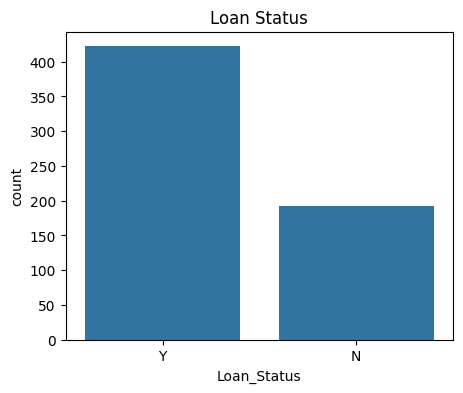

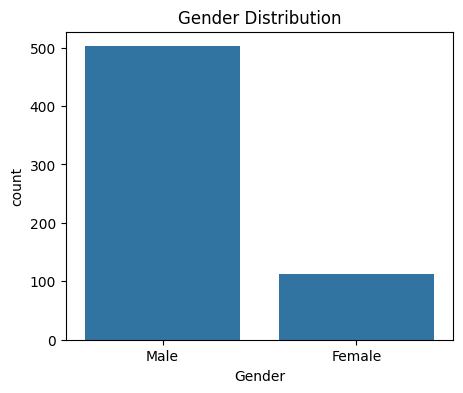

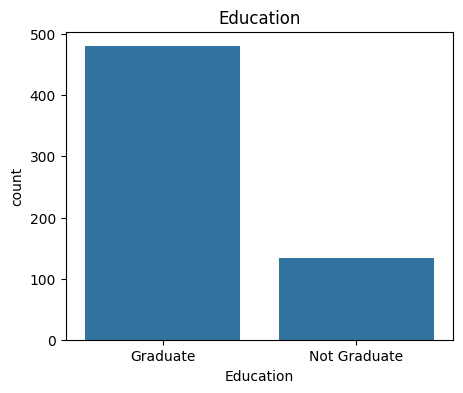

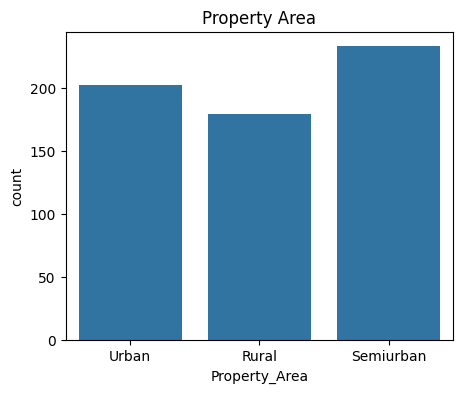

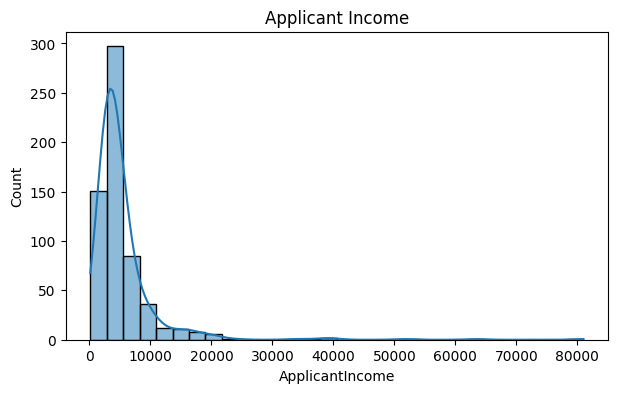

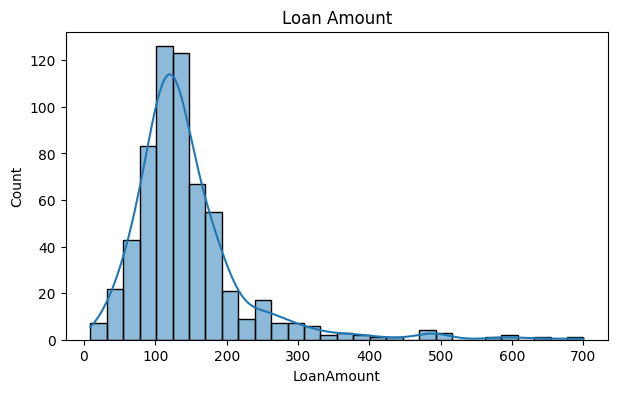

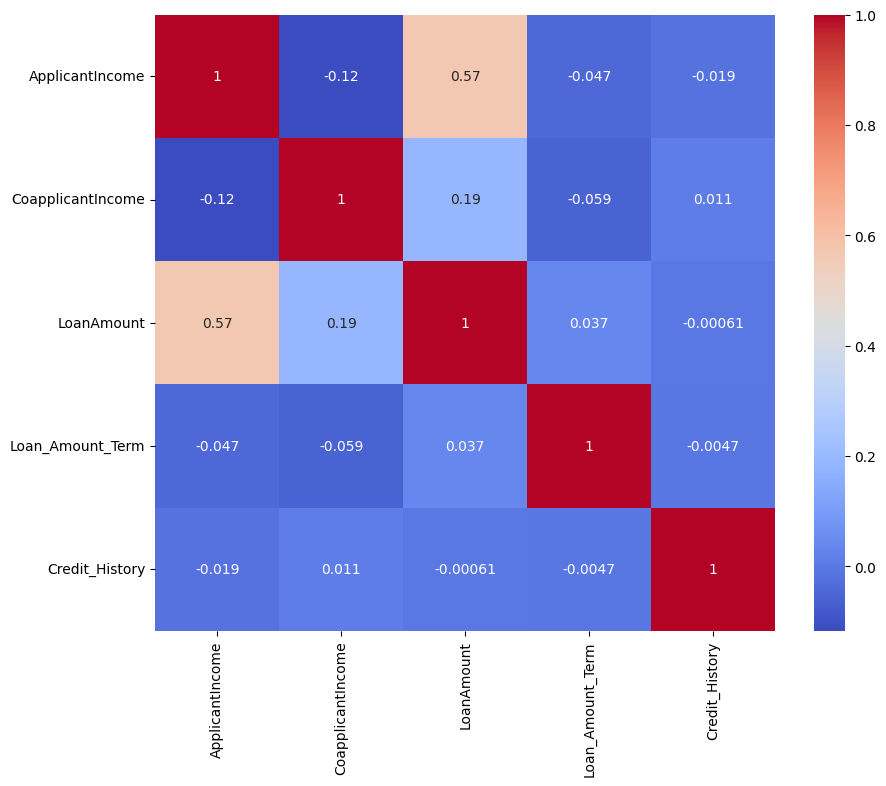

In [60]:
# ======================================
# EXPLORATORY DATA ANALYSIS
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

print(df.describe())

# Loan Status
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Loan_Status')
plt.title("Loan Status")
plt.show()

# Gender
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Gender')
plt.title("Gender Distribution")
plt.show()

# Education
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Education')
plt.title("Education")
plt.show()

# Property Area
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Property_Area')
plt.title("Property Area")
plt.show()

# Applicant Income
plt.figure(figsize=(7,4))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title("Applicant Income")
plt.show()

# Loan Amount
plt.figure(figsize=(7,4))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount")
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [61]:
print(df['Loan_Status'].unique())
print(df['Loan_Status'].value_counts(dropna=False))

['Y' 'N']
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [62]:
# ======================================
# FEATURE ENGINEERING
# ======================================

# Clean target column
df['Loan_Status'] = df['Loan_Status'].astype(str).str.strip()

# Convert target to numbers
df['Loan_Status'] = df['Loan_Status'].replace({
    'Y':1,
    'N':0
})

# Remove invalid rows if any
df = df[df['Loan_Status'].isin([0,1])]

# Convert to integer
df['Loan_Status'] = df['Loan_Status'].astype(int)

print(df['Loan_Status'].value_counts())

# Separate Features and Target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Save Feature Names
feature_columns = X.columns.tolist()

print("Total Features :", len(feature_columns))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Loan_Status
1    422
0    192
Name: count, dtype: int64
Total Features : 14
Training Shape : (491, 14)
Testing Shape : (123, 14)


/tmp/ipykernel_5765/3639960820.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Loan_Status'] = df['Loan_Status'].replace({


In [63]:
# ==========================================
# MODEL TRAINING
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Accuracy: 84.55 %
              precision    recall  f1-score   support

           0       0.81      0.66      0.72        38
           1       0.86      0.93      0.89        85

    accuracy                           0.85       123
   macro avg       0.83      0.79      0.81       123
weighted avg       0.84      0.85      0.84       123



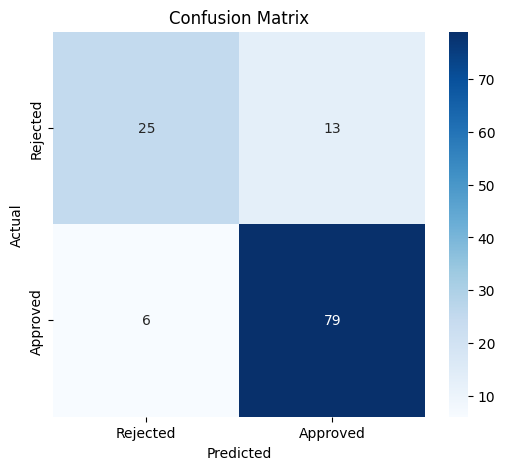

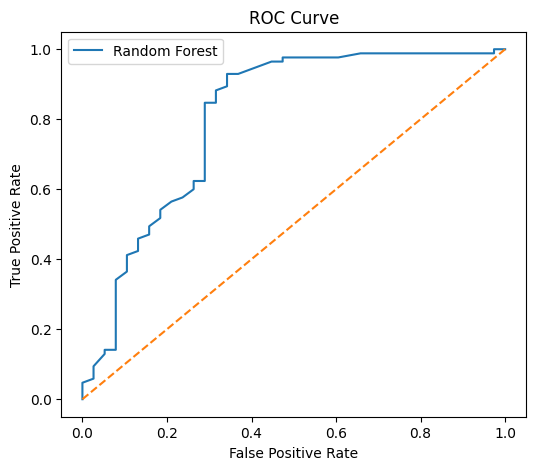

ROC AUC Score: 0.8041795665634676


In [64]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("Accuracy:", round(accuracy*100,2), "%")
print("="*50)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, prob))

In [65]:
# ==========================================
# SAVE MODEL
# ==========================================

import joblib

joblib.dump(model, "loan_prediction_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


In [66]:
# ==========================================
# LOAD SAVED MODEL
# ==========================================

loaded_model = joblib.load("loan_prediction_model.pkl")
loaded_features = joblib.load("feature_columns.pkl")

print("Model loaded successfully!")

print("Number of Features:", len(loaded_features))
print("First 10 Features:")
print(loaded_features[:10])

Model loaded successfully!
Number of Features: 14
First 10 Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+']


In [67]:
from google.colab import files

files.download("loan_prediction_model.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
!pip install -q gradio joblib

In [69]:
import gradio as gr
import pandas as pd
import joblib

In [70]:
model = joblib.load("loan_prediction_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [71]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_term,
    credit_history,
    property_area
):

    data = {
        "ApplicantIncome": applicant_income,
        "CoapplicantIncome": coapplicant_income,
        "LoanAmount": loan_amount,
        "Loan_Amount_Term": loan_term,
        "Credit_History": credit_history,

        "Gender_Male": 1 if gender=="Male" else 0,

        "Married_Yes": 1 if married=="Yes" else 0,

        "Dependents_1": 1 if dependents=="1" else 0,
        "Dependents_2": 1 if dependents=="2" else 0,
        "Dependents_3+": 1 if dependents=="3+" else 0,

        "Education_Not Graduate": 1 if education=="Not Graduate" else 0,

        "Self_Employed_Yes": 1 if self_employed=="Yes" else 0,

        "Property_Area_Semiurban": 1 if property_area=="Semiurban" else 0,
        "Property_Area_Urban": 1 if property_area=="Urban" else 0
    }

    input_df = pd.DataFrame([data])

    input_df = input_df.reindex(
        columns=feature_columns,
        fill_value=0
    )

    prediction = model.predict(input_df)[0]

    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        return f"✅ Loan Approved\n\nApproval Probability: {probability*100:.2f}%"

    else:
        return f"❌ Loan Rejected\n\nApproval Probability: {probability*100:.2f}%"

In [72]:
demo = gr.Interface(
    fn=predict_loan,

    inputs=[
        gr.Dropdown(["Male","Female"],label="Gender"),

        gr.Dropdown(["Yes","No"],label="Married"),

        gr.Dropdown(["0","1","2","3+"],label="Dependents"),

        gr.Dropdown(
            ["Graduate","Not Graduate"],
            label="Education"
        ),

        gr.Dropdown(
            ["Yes","No"],
            label="Self Employed"
        ),

        gr.Number(label="Applicant Income"),

        gr.Number(label="Coapplicant Income"),

        gr.Number(label="Loan Amount"),

        gr.Number(label="Loan Amount Term"),

        gr.Dropdown(["1","0"],label="Credit History"),

        gr.Dropdown(
            ["Rural","Semiurban","Urban"],
            label="Property Area"
        )

    ],

    outputs=gr.Textbox(label="Prediction"),

    title="🏦 Smart Lender Loan Prediction",

    description="Enter applicant details to predict loan approval."
)

In [73]:
demo.launch(
    debug=True,
    share=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://eb8f50f4e3a3c9c725.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://eb8f50f4e3a3c9c725.gradio.live
